In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("v1.csv")
df.head()

,student_id,strata,semester,ip_semester,ipk_total,sks_semester,total_sks,sks_lulus,sks_tidak_lulus,label_kelulusan
0,1,S1,1,2.936,2.936,18,18,17,1,lulus_tepat_waktu
1,1,S1,2,3.236,3.094,20,38,37,1,lulus_tepat_waktu
2,1,S1,3,2.416,2.831,24,62,57,5,lulus_tepat_waktu
3,1,S1,4,2.933,2.853,17,79,73,6,lulus_tepat_waktu
4,1,S1,5,2.809,2.844,20,99,92,7,lulus_tepat_waktu


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34083 entries, 0 to 34082
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   student_id       34083 non-null  int64  
 1   strata           34083 non-null  str    
 2   semester         34083 non-null  int64  
 3   ip_semester      34083 non-null  float64
 4   ipk_total        34083 non-null  float64
 5   sks_semester     34083 non-null  int64  
 6   total_sks        34083 non-null  int64  
 7   sks_lulus        34083 non-null  int64  
 8   sks_tidak_lulus  34083 non-null  int64  
 9   label_kelulusan  34083 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 2.6 MB


In [6]:
from datagen import generate_data_sintetis

df = generate_data_sintetis(n_students=5000, strata_distribution={"S1": 0.7, "S2": 0.2, "S3": 0.1}, random_seed=687566)
df.head(10)

,student_id,strata,semester,ip_semester,ipk_total,sks_semester,total_sks,sks_lulus,sks_tidak_lulus,label_kelulusan
0,1,S1,1,3.454,3.454,22,22,22,0,lulus_tepat_waktu
1,1,S1,2,3.064,3.259,22,44,44,0,lulus_tepat_waktu
2,1,S1,3,4.000,3.498,21,65,65,0,lulus_tepat_waktu
3,1,S1,4,3.267,3.436,24,89,89,0,lulus_tepat_waktu
4,1,S1,5,3.385,3.426,22,111,111,0,lulus_tepat_waktu
5,1,S1,6,4.000,3.528,24,135,135,0,lulus_tepat_waktu
6,1,S1,7,3.171,3.476,23,158,157,1,lulus_tepat_waktu
7,2,S1,1,3.078,3.078,21,21,21,0,lulus_tepat_waktu
8,2,S1,2,3.235,3.158,22,43,42,1,lulus_tepat_waktu
9,2,S1,3,3.465,3.268,24,67,66,1,lulus_tepat_waktu


In [14]:
grouped_df = df.groupby("student_id").agg({
    "strata": "first",
    "semester": "max",
    "ipk_total": "last",
    "total_sks": "last",
    "sks_lulus": "last",
    "sks_tidak_lulus": "last",
    "label_kelulusan": "last"
}).reset_index()
grouped_df

,student_id,strata,semester,ipk_total,total_sks,sks_lulus,sks_tidak_lulus,label_kelulusan
0,1,S1,7,3.476,158,157,1,lulus_tepat_waktu
1,2,S1,8,2.920,166,156,10,lulus_tepat_waktu
2,3,S1,9,2.610,169,155,14,lulus_terlambat
3,4,S1,10,2.384,176,146,30,lulus_terlambat
4,5,S1,11,2.160,184,150,34,lulus_terlambat
...,...,...,...,...,...,...,...,...
4995,4996,S1,7,3.175,153,149,4,lulus_tepat_waktu
4996,4997,S2,3,2.316,60,53,7,lulus_tepat_waktu
4997,4998,S2,3,2.372,49,41,8,lulus_tepat_waktu
4998,4999,S2,3,2.225,57,47,10,lulus_tepat_waktu


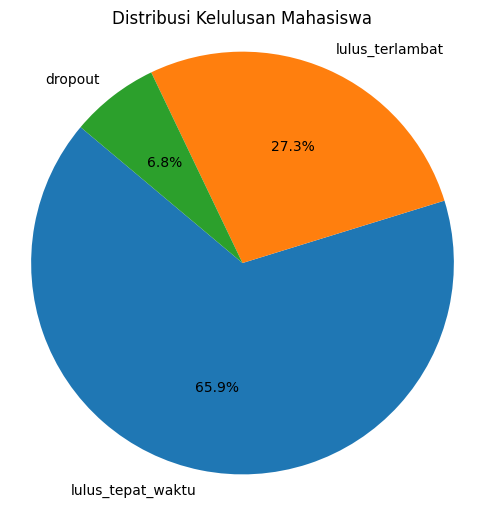

In [8]:
# status pie chart
status_counts = grouped_df["label_kelulusan"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Distribusi Kelulusan Mahasiswa")
plt.axis("equal")
plt.show()

In [14]:
status_counts

label_kelulusan
lulus_tepat_waktu    3281
lulus_terlambat      1454
dropout               265
Name: count, dtype: int64

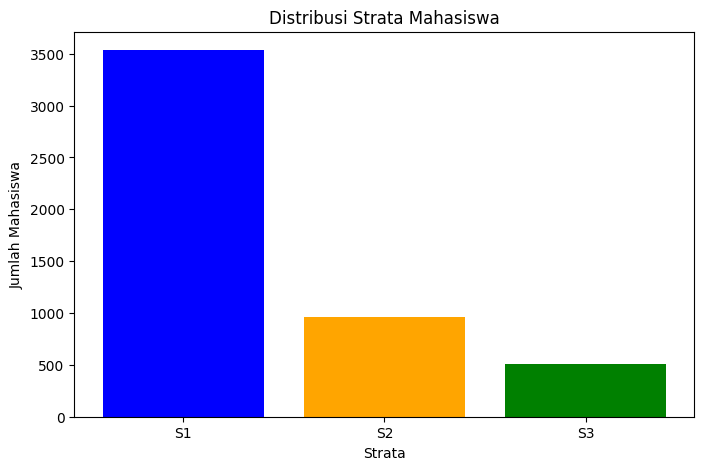

In [5]:
# strata bar chart
strata_counts = grouped_df["strata"].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(strata_counts.index, strata_counts.values, color=["blue", "orange", "green"])
plt.title("Distribusi Strata Mahasiswa")
plt.xlabel("Strata")
plt.ylabel("Jumlah Mahasiswa")
plt.show()

In [16]:
grouped_df[grouped_df["label_kelulusan"] == "dropout"]

,student_id,strata,semester,ipk_total,total_sks,sks_lulus,sks_tidak_lulus,label_kelulusan
6,7,S2,3,1.510,54,39,15,dropout
9,10,S1,11,1.994,191,151,40,dropout
14,15,S1,12,1.582,204,152,52,dropout
23,24,S1,12,1.886,197,146,51,dropout
26,27,S2,3,1.466,57,44,13,dropout
...,...,...,...,...,...,...,...,...
4948,4949,S1,11,1.967,191,147,44,dropout
4955,4956,S1,12,1.616,196,146,50,dropout
4957,4958,S2,3,1.992,51,40,11,dropout
4991,4992,S3,4,1.603,67,50,17,dropout
